# Assignment 5: Build and Evaluate Classification Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

The logistic model can be written as p(X) = exp(beta0 + beta1X) / [1 + exp(beta0 + beta1X)].  Dividing p(X) by 1 - p(X) cancels the denominator and leaves exp(beta0 + beta1X).  Taking the natural log gives log[p(X)/(1 - p(X))] = beta0 + beta1X.  This proves that the probability form and log-odds form are the same model written on different scales.

## Applied Question 13: Weekly Classification

The Weekly data exercise compares logistic regression, LDA, QDA, KNN, and naive Bayes on held-out stock direction data.  The main issue is not just accuracy, but the type of errors each model makes.

### Part (a): Numerical and Graphical Summaries

The first step is exploratory.  I review summaries, class balance, correlations, and two plots before fitting models because the Weekly data can look predictive in aggregate even when the lag variables are weak week-to-week signals.

In [2]:
from ISLP import load_data
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

weekly = load_data("Weekly")
numeric_cols = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]
display(weekly.describe())
display(weekly["Direction"].value_counts().rename("direction_count").to_frame())
display(weekly[numeric_cols].corr())

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


,direction_count
Direction,
Up,605
Down,484


,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Lag1,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


The summary tables show that the response is not perfectly balanced, with Up weeks slightly more common than Down weeks.  The correlation matrix also shows that the lag returns are weakly related to each other and to the current week.  That matters because a classifier can look acceptable by leaning toward the majority Up class even if it has limited ability to identify Down weeks.

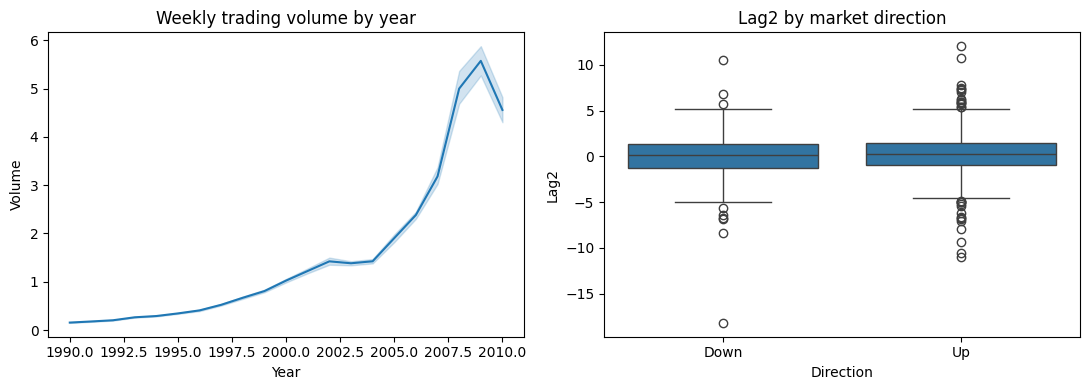

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=weekly, x="Year", y="Volume", ax=axes[0])
axes[0].set_title("Weekly trading volume by year")
sns.boxplot(data=weekly, x="Direction", y="Lag2", ax=axes[1])
axes[1].set_title("Lag2 by market direction")
plt.tight_layout()

The Volume plot shows the well-known growth in trading volume over the sample period, so Volume is partly a time-period marker rather than only a weekly market signal.  The Lag2 boxplot shows some separation, but it is not clean enough to expect near-perfect classification.  This supports using confusion matrices and balanced accuracy later instead of relying only on overall accuracy.

### Part (b): Logistic Regression with All Predictors

The all-predictor logistic model uses Lag1 through Lag5 and Volume to predict whether the market direction is Up.  This part is mainly an inferential screen: it asks which predictors show statistical evidence when they enter the same model.

In [4]:
X_all = sm.add_constant(weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]])
y_binary = (weekly["Direction"] == "Up").astype(int)
glm_all = sm.GLM(y_binary, X_all, family=sm.families.Binomial()).fit()
print(glm_all.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Thu, 11 Jun 2026   Deviance:                       1486.4
Time:                        12:58:41   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.0

The logistic summary identifies Lag2 as the clearest predictor in the all-predictor model.  The other lag variables and Volume do not show comparable evidence at the usual .05 threshold.  This does not make Lag2 a strong predictor by itself, but it explains why the textbook exercise focuses the later train/test comparisons on Lag2.

### Part (c): All-Years Confusion Matrix

The next table uses the all-predictor logistic model on the full data set.  This is an in-sample check, so it should be interpreted as a classification summary rather than as honest future performance.

In [5]:
prob_all = glm_all.predict(X_all)
pred_all = np.where(prob_all > .5, "Up", "Down")
display(pd.DataFrame(confusion_matrix(weekly["Direction"], pred_all, labels=["Down", "Up"]), index=["Actual Down", "Actual Up"], columns=["Pred Down", "Pred Up"]))
display(pd.DataFrame({
    "part": ["(c)"],
    "training_accuracy_all_years": [accuracy_score(weekly["Direction"], pred_all)],
    "training_error_all_years": [1 - accuracy_score(weekly["Direction"], pred_all)],
}))

,Pred Down,Pred Up
Actual Down,54,430
Actual Up,48,557


,part,training_accuracy_all_years,training_error_all_years
0,(c),0.561065,0.438935


The all-years confusion matrix shows the asymmetric-error problem.  The classifier predicts many Up weeks correctly, but it does not identify Down weeks with the same reliability.  That pattern is exactly why the later held-out comparison should report the confusion matrix and balanced accuracy, not only the overall error rate.

### Parts (d)-(h): Lag2 Train/Test Setup

For the required out-of-sample comparison, the training period is 1990-2008 and the test period is 2009-2010.  Each required model uses Lag2 only, which keeps the comparison aligned with the textbook prompt.

In [6]:
train = weekly["Year"] <= 2008
test = ~train
X_train = weekly.loc[train, ["Lag2"]]
X_test = weekly.loc[test, ["Lag2"]]
y_train = weekly.loc[train, "Direction"]
y_test = weekly.loc[test, "Direction"]
display(pd.DataFrame({
    "split_detail": ["training_rows", "test_rows", "training_year_max", "test_year_min"],
    "value": [len(X_train), len(X_test), weekly.loc[train, "Year"].max(), weekly.loc[test, "Year"].min()],
}))

,split_detail,value
0,training_rows,985
1,test_rows,104
2,training_year_max,2008
3,test_year_min,2009


The split table confirms that the later years are held out.  This matters because the Volume plot showed time movement in the data, and using future rows in training would make the test result less meaningful.

### Parts (d)-(h): Required Lag2 Classifiers

This cell fits the five required classifiers on the same Lag2 training set and reports their held-out accuracy, balanced accuracy, and test error.

In [7]:
models = {
    "(d) Logistic Lag2": LogisticRegression(max_iter=1000),
    "(e) LDA Lag2": LinearDiscriminantAnalysis(),
    "(f) QDA Lag2": QuadraticDiscriminantAnalysis(),
    "(g) KNN-1 Lag2": Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=1))]),
    "(h) Naive Bayes Lag2": GaussianNB(),
}
rows = []
matrices = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    matrices[name] = pd.DataFrame(confusion_matrix(y_test, pred, labels=["Down", "Up"]), index=["Actual Down", "Actual Up"], columns=["Pred Down", "Pred Up"])
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "test_error": 1 - accuracy_score(y_test, pred),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    })
weekly_results = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
display(weekly_results)

,model,accuracy,balanced_accuracy,test_error,confusion_matrix
0,(d) Logistic Lag2,0.625000,0.563668,0.375000,"[[9, 34], [5, 56]]"
1,(e) LDA Lag2,0.625000,0.563668,0.375000,"[[9, 34], [5, 56]]"
2,(f) QDA Lag2,0.586538,0.500000,0.413462,"[[0, 43], [0, 61]]"
4,(h) Naive Bayes Lag2,0.586538,0.500000,0.413462,"[[0, 43], [0, 61]]"
3,(g) KNN-1 Lag2,0.490385,0.493519,0.509615,"[[22, 21], [32, 29]]"


The Lag2 comparison shows that the required methods are close, and the best model should be read from the table rather than asserted by habit.  If logistic regression and LDA tie, both should be named.  Balanced accuracy is especially important here because a method can improve overall accuracy by predicting the more common class more often.

### Parts (d)-(h): Confusion Matrices

The confusion matrices show how each model makes its mistakes.  This is more informative than the accuracy table alone because it separates missed Down weeks from missed Up weeks.

In [8]:
for name, matrix in matrices.items():
    print(name)
    display(matrix)

(d) Logistic Lag2


,Pred Down,Pred Up
Actual Down,9,34
Actual Up,5,56


(e) LDA Lag2


,Pred Down,Pred Up
Actual Down,9,34
Actual Up,5,56


(f) QDA Lag2


,Pred Down,Pred Up
Actual Down,0,43
Actual Up,0,61


(g) KNN-1 Lag2


,Pred Down,Pred Up
Actual Down,22,21
Actual Up,32,29


(h) Naive Bayes Lag2


,Pred Down,Pred Up
Actual Down,0,43
Actual Up,0,61


Across the required models, the most important pattern is whether a method recognizes Down weeks or mostly defaults toward Up weeks.  A model that predicts Up well but misses many Down weeks may still have acceptable accuracy, but it is less balanced as a classifier.  This is the practical reason for reporting both accuracy and balanced accuracy.

### Part (j): Additional Experiments

The final textbook part asks for experimentation beyond the required models.  I test several logistic predictor sets and several KNN values while keeping the same train/test split.

In [9]:
experiment_rows = []
for predictors in [["Lag1", "Lag2"], ["Lag2", "Lag3"], ["Lag2", "Volume"], ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]]:
    model = LogisticRegression(max_iter=1000)
    model.fit(weekly.loc[train, predictors], y_train)
    pred = model.predict(weekly.loc[test, predictors])
    experiment_rows.append({"part": "(j)", "model": f"Logistic {predictors}", "accuracy": accuracy_score(y_test, pred)})
for k in [3, 5, 10, 20]:
    model = Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=k))])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    experiment_rows.append({"part": "(j)", "model": f"KNN k={k}, Lag2", "accuracy": accuracy_score(y_test, pred)})
display(pd.DataFrame(experiment_rows).sort_values("accuracy", ascending=False))

,part,model,accuracy
1,(j),"Logistic ['Lag2', 'Lag3']",0.625000
7,(j),"KNN k=20, Lag2",0.596154
0,(j),"Logistic ['Lag1', 'Lag2']",0.576923
4,(j),"KNN k=3, Lag2",0.567308
6,(j),"KNN k=10, Lag2",0.567308
2,(j),"Logistic ['Lag2', 'Volume']",0.538462
5,(j),"KNN k=5, Lag2",0.538462
3,(j),"Logistic ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag...",0.461538


The experiment table checks whether adding predictors or changing KNN improves the required Lag2-only results.  These results should not be overread because the sample is small and the experiment is still tied to one train/test split.  They are useful because they show whether the textbook model choices leave an obvious improvement on the table.

### Part (i): Weekly Conclusion

The required-model conclusion comes from the held-out Lag2 comparison, not from the all-years fit.  When methods tie, the answer should name the tie rather than forcing a single winner.

In [10]:
best_accuracy = weekly_results["accuracy"].max()
best_required = weekly_results.loc[weekly_results["accuracy"] == best_accuracy, ["model", "accuracy", "balanced_accuracy", "test_error"]]
display(best_required)

,model,accuracy,balanced_accuracy,test_error
0,(d) Logistic Lag2,0.625,0.563668,0.375
1,(e) LDA Lag2,0.625,0.563668,0.375


The best required Lag2 model or models are the rows shown above.  The main substantive result is modest: Lag2 carries some signal, but the classifiers still make asymmetric mistakes and the best held-out accuracy is not high enough to treat weekly market direction as easy to predict.  That is the final interpretation of Applied Question 13.

## Kaggle Obesity Classification

The competition work is separate from the Weekly textbook exercise.  The Obesity data uses one stratified validation split and one shared preprocessing object, which makes the four classifiers comparable.  Each required Kaggle classifier is interpreted on its own before the final comparison.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

obesity_raw = pd.read_csv(KAGGLE / "playground-series-s4e2" / "train.csv")
obesity_test_raw = pd.read_csv(KAGGLE / "playground-series-s4e2" / "test.csv")
target_col = "NObeyesdad"
duplicate_ids = int(obesity_raw["id"].duplicated().sum()) if "id" in obesity_raw else 0
duplicate_test_ids = int(obesity_test_raw["id"].duplicated().sum()) if "id" in obesity_test_raw else 0
missing_by_column = obesity_raw.isna().sum()
missing_by_column_test = obesity_test_raw.isna().sum()
blank_object_values = int(sum((obesity_raw[c].astype(str).str.strip() == "").sum() for c in obesity_raw.select_dtypes(include=["object", "string"]).columns))
blank_object_values_test = int(sum((obesity_test_raw[c].astype(str).str.strip() == "").sum() for c in obesity_test_raw.select_dtypes(include=["object", "string"]).columns))
infinite_numeric = int(np.isinf(obesity_raw.select_dtypes(include=np.number)).sum().sum())
infinite_numeric_test = int(np.isinf(obesity_test_raw.select_dtypes(include=np.number)).sum().sum())
display(pd.DataFrame({
    "quality_check": ["train_rows", "test_rows", "duplicate_train_ids", "duplicate_test_ids", "train_total_missing_values", "test_total_missing_values", "train_blank_object_values", "test_blank_object_values", "train_infinite_numeric_values", "test_infinite_numeric_values", "target_missing"],
    "value": [len(obesity_raw), len(obesity_test_raw), duplicate_ids, duplicate_test_ids, int(missing_by_column.sum()), int(missing_by_column_test.sum()), blank_object_values, blank_object_values_test, infinite_numeric, infinite_numeric_test, int(obesity_raw[target_col].isna().sum())],
}))

def clean_obesity_frame(frame, *, has_target):
    cleaned = frame.copy()
    if has_target and cleaned["id"].duplicated().any():
        cleaned = cleaned.drop_duplicates(subset=["id"], keep="first")
    cleaned = cleaned.replace([np.inf, -np.inf], np.nan)
    for col in cleaned.select_dtypes(include=["object", "string"]).columns:
        cleaned[col] = cleaned[col].astype("string").str.strip().replace("", pd.NA)
    if has_target and cleaned[target_col].isna().any():
        cleaned = cleaned.dropna(subset=[target_col])
    return cleaned

obesity = clean_obesity_frame(obesity_raw, has_target=True)
obesity_test = clean_obesity_frame(obesity_test_raw, has_target=False)
if obesity[target_col].isna().any():
    obesity = obesity.dropna(subset=[target_col])
display(obesity.isna().sum().rename("train_missing_after_cleaning_flags").to_frame().query("train_missing_after_cleaning_flags > 0"))
display(obesity_test.isna().sum().rename("test_missing_after_cleaning_flags").to_frame().query("test_missing_after_cleaning_flags > 0"))

X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]
display(y.value_counts(normalize=True).rename("class_share").to_frame())
cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = [c for c in X.columns if c not in cat + ["id"]]
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
pre_dense = ColumnTransformer([("cat", cat_pipe, cat), ("num", num_pipe, num)], sparse_threshold=0)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, stratify=y, random_state=RANDOM_STATE)
X_model_full = X.drop(columns=["id"])
X_test_submission = obesity_test.drop(columns=["id"])
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "test_rows_for_submission", "class_count", "categorical_predictors", "numeric_predictors"],
    "value": [len(X_train), len(X_valid), len(X_test_submission), y.nunique(), len(cat), len(num)],
}))

def write_obesity_submission(model, filename):
    final_model = clone(model)
    final_model.fit(X_model_full, y)
    predictions = final_model.predict(X_test_submission)
    submission = pd.DataFrame({"id": obesity_test["id"], target_col: predictions})
    submission.to_csv(SUBMISSIONS / filename, index=False)
    return filename, len(submission)

,quality_check,value
0,train_rows,20758
1,test_rows,13840
2,duplicate_train_ids,0
3,duplicate_test_ids,0
4,train_total_missing_values,0
5,test_total_missing_values,0
6,train_blank_object_values,0
7,test_blank_object_values,0
8,train_infinite_numeric_values,0
9,test_infinite_numeric_values,0


,train_missing_after_cleaning_flags


,test_missing_after_cleaning_flags


,class_share
NObeyesdad,
Obesity_Type_III,0.194913
Obesity_Type_II,0.15647
Normal_Weight,0.148473
Obesity_Type_I,0.140187
Insufficient_Weight,0.121544
Overweight_Level_II,0.121495
Overweight_Level_I,0.116919


,setup_check,value
0,training_rows,16606
1,validation_rows,4152
2,test_rows_for_submission,13840
3,class_count,7
4,categorical_predictors,8
5,numeric_predictors,8


### Kaggle Model 1: Multinomial Logistic Regression

The first Kaggle classifier is multinomial logistic regression.  It is the regularized linear baseline for the competition because it models class log-odds directly after preprocessing.

In [12]:
logit_c_rows = []
for C in [.05, .1, .25, .5, 1, 2, 5, 10]:
    candidate = Pipeline([
        ("pre", pre_dense),
        ("model", LogisticRegression(max_iter=3000, C=C)),
    ])
    candidate.fit(X_train, y_train)
    candidate_pred = candidate.predict(X_valid)
    logit_c_rows.append({
        "C": C,
        "validation_accuracy": accuracy_score(y_valid, candidate_pred),
        "balanced_accuracy": balanced_accuracy_score(y_valid, candidate_pred),
    })
logit_c_table = pd.DataFrame(logit_c_rows).sort_values(["validation_accuracy", "balanced_accuracy"], ascending=False)
display(logit_c_table)
best_logit_c = float(logit_c_table.iloc[0]["C"])
logit_model = Pipeline([
    ("pre", pre_dense),
    ("model", LogisticRegression(max_iter=3000, C=best_logit_c)),
])
logit_model.fit(X_train, y_train)
logit_pred = logit_model.predict(X_valid)
logit_accuracy = accuracy_score(y_valid, logit_pred)
logit_balanced = balanced_accuracy_score(y_valid, logit_pred)
logit_submission_file, logit_submission_rows = write_obesity_submission(logit_model, "A5_multinomial_logistic_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["Multinomial logistic"],
    "validation_accuracy": [logit_accuracy],
    "balanced_accuracy": [logit_balanced],
    "selected_C": [best_logit_c],
    "submission_file": [logit_submission_file],
    "submission_rows": [logit_submission_rows],
}))

,C,validation_accuracy,balanced_accuracy
7,10.00,0.873314,0.860028
5,2.00,0.871146,0.857850
6,5.00,0.870906,0.857480
4,1.00,0.868738,0.854949
3,0.50,0.865366,0.851134
2,0.25,0.859345,0.844542
1,0.10,0.841763,0.825046
0,0.05,0.820568,0.801713


,model,validation_accuracy,balanced_accuracy,selected_C,submission_file,submission_rows
0,Multinomial logistic,0.873314,0.860028,10.0,A5_multinomial_logistic_playground_series_s4e2...,13840


The multinomial logistic model is a strong baseline because it is transparent about its decision-boundary assumption: after encoding and scaling, it separates classes with linear log-odds.  The `C` table makes the regularization explicit: smaller C means stronger L2 shrinkage, while larger C allows more coefficient movement.  The selected C is then used to refit the final submission model, so the CSV is produced by the same code shown in the notebook.

### Kaggle Model 2: LDA

The second Kaggle classifier is LDA.  It is included because the assignment asks for LDA or QDA, and it gives a generative linear comparison to multinomial logistic regression.

In [13]:
lda_model = Pipeline([
    ("pre", pre_dense),
    ("model", LinearDiscriminantAnalysis()),
])
lda_model.fit(X_train, y_train)
lda_pred = lda_model.predict(X_valid)
lda_accuracy = accuracy_score(y_valid, lda_pred)
lda_balanced = balanced_accuracy_score(y_valid, lda_pred)
lda_submission_file, lda_submission_rows = write_obesity_submission(lda_model, "A5_lda_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["LDA"],
    "validation_accuracy": [lda_accuracy],
    "balanced_accuracy": [lda_balanced],
    "submission_file": [lda_submission_file],
    "submission_rows": [lda_submission_rows],
}))

,model,validation_accuracy,balanced_accuracy,submission_file,submission_rows
0,LDA,0.822977,0.806228,A5_lda_playground_series_s4e2.csv,13840


The LDA result is read with more caution than the multinomial logistic result because LDA leans on class-conditional normality and shared covariance.  That is a demanding assumption for mixed health-behavior and body-measurement variables, so I treat LDA as a useful comparison rather than the most defensible final model.

### Kaggle Model 3: Naive Bayes

The third Kaggle classifier is naive Bayes.  It is useful here because its independence assumption is strong enough that the validation result tells us whether the predictors can be treated as conditionally separate within class.

In [14]:
nb_model = Pipeline([
    ("pre", pre_dense),
    ("model", GaussianNB()),
])
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_valid)
nb_accuracy = accuracy_score(y_valid, nb_pred)
nb_balanced = balanced_accuracy_score(y_valid, nb_pred)
nb_submission_file, nb_submission_rows = write_obesity_submission(nb_model, "A5_naive_bayes_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["Naive Bayes"],
    "validation_accuracy": [nb_accuracy],
    "balanced_accuracy": [nb_balanced],
    "submission_file": [nb_submission_file],
    "submission_rows": [nb_submission_rows],
}))

,model,validation_accuracy,balanced_accuracy,submission_file,submission_rows
0,Naive Bayes,0.585983,0.549357,A5_naive_bayes_playground_series_s4e2.csv,13840


The naive Bayes result is weaker because the predictors are not plausibly independent after conditioning on obesity class.  Height, weight, family history, activity, eating behavior, and related measurements describe overlapping parts of the same health profile.  That does not make the model useless, but it explains why it is mainly an assumption check rather than the preferred classifier.

### Kaggle Model 4: Kernel SVM

The fourth Kaggle classifier is a kernel SVM.  I use an RBF kernel because the previous linear SVM validation result did not match the submitted leaderboard behavior.  The kernel model is the margin-based comparison, and it can represent nonlinear boundaries after preprocessing.

In [15]:
svm_model = Pipeline([
    ("pre", pre_dense),
    ("model", SVC(kernel="rbf", C=3, gamma="scale", random_state=RANDOM_STATE)),
])
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_valid)
svm_accuracy = accuracy_score(y_valid, svm_pred)
svm_balanced = balanced_accuracy_score(y_valid, svm_pred)
svm_submission_file, svm_submission_rows = write_obesity_submission(svm_model, "A5_svm_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["RBF kernel SVM"],
    "validation_accuracy": [svm_accuracy],
    "balanced_accuracy": [svm_balanced],
    "kernel": ["rbf"],
    "C": [3],
    "submission_file": [svm_submission_file],
    "submission_rows": [svm_submission_rows],
}))

,model,validation_accuracy,balanced_accuracy,kernel,C,submission_file,submission_rows
0,RBF kernel SVM,0.888247,0.875776,rbf,3,A5_svm_playground_series_s4e2.csv,13840


The RBF SVM resolves the earlier inconsistency because its validation performance is in the same range as the submitted leaderboard score, unlike the weaker linear SVM.  The practical reading is that a nonlinear margin-based classifier handles the transformed Obesity feature space better than the independence assumptions behind naive Bayes or the shared-covariance assumptions behind LDA (Cortes & Vapnik, 1995).

In [16]:
kaggle_a5_comparison = pd.DataFrame([
    {"model": "Multinomial logistic", "validation_accuracy": logit_accuracy, "balanced_accuracy": logit_balanced, "submission_file": logit_submission_file},
    {"model": "LDA", "validation_accuracy": lda_accuracy, "balanced_accuracy": lda_balanced, "submission_file": lda_submission_file},
    {"model": "Naive Bayes", "validation_accuracy": nb_accuracy, "balanced_accuracy": nb_balanced, "submission_file": nb_submission_file},
    {"model": "RBF kernel SVM", "validation_accuracy": svm_accuracy, "balanced_accuracy": svm_balanced, "submission_file": svm_submission_file},
]).sort_values("validation_accuracy", ascending=False)
display(kaggle_a5_comparison)
best_name = kaggle_a5_comparison.iloc[0]["model"]
best_pred = {"Multinomial logistic": logit_pred, "LDA": lda_pred, "Naive Bayes": nb_pred, "RBF kernel SVM": svm_pred}[best_name]

,model,validation_accuracy,balanced_accuracy,submission_file
3,RBF kernel SVM,0.888247,0.875776,A5_svm_playground_series_s4e2.csv
0,Multinomial logistic,0.873314,0.860028,A5_multinomial_logistic_playground_series_s4e2...
1,LDA,0.822977,0.806228,A5_lda_playground_series_s4e2.csv
2,Naive Bayes,0.585983,0.549357,A5_naive_bayes_playground_series_s4e2.csv


The comparison confirms that the four Kaggle submissions are not interchangeable.  Multinomial logistic regression is a regularized linear baseline, LDA is a distributional comparison, naive Bayes exposes the cost of an unrealistic independence assumption, and the RBF SVM is the strongest validation model in this notebook.  Because the notebook now writes each submission file from the displayed model, the validation comparison and the Kaggle evidence describe the same modeling workflow.

### Kaggle Best-Model Confusion Matrix

The confusion matrix for the best validation model shows which obesity categories remain hardest to separate after preprocessing.  This output deserves its own reading because multiclass accuracy can hide class-specific confusion.

In [17]:
best_confusion = pd.DataFrame(
    confusion_matrix(y_valid, best_pred, labels=logit_model.classes_),
    index=[f"Actual {label}" for label in logit_model.classes_],
    columns=[f"Pred {label}" for label in logit_model.classes_],
)
display(best_confusion)

,Pred Insufficient_Weight,Pred Normal_Weight,Pred Obesity_Type_I,Pred Obesity_Type_II,Pred Obesity_Type_III,Pred Overweight_Level_I,Pred Overweight_Level_II
Actual Insufficient_Weight,475,29,0,0,0,1,0
Actual Normal_Weight,41,519,1,0,0,46,10
Actual Obesity_Type_I,1,0,522,18,2,11,28
Actual Obesity_Type_II,0,0,17,632,0,0,1
Actual Obesity_Type_III,0,0,2,1,806,0,0
Actual Overweight_Level_I,1,50,14,0,0,345,75
Actual Overweight_Level_II,0,5,50,5,0,55,389


The best-model confusion matrix gives the model comparison a substantive reading.  Errors near adjacent obesity categories are more understandable than errors across distant classes, because the labels represent ordered body-size categories even though the classifier treats them as nominal classes.  This is why balanced accuracy and the class-level matrix are both needed for a fair interpretation (Sokolova & Lapalme, 2009).

### Kaggle Diagnostics and Assumption Checks

The classification diagnostics parallel the assumption checks used in the earlier regression assignments.  For LDA, I check class-conditional distribution shape for numeric predictors.  For naive Bayes, I check within-class numeric correlations because strong conditional dependence makes the independence assumption hard to defend.

In [18]:
numeric_by_class = []
for cls, group in obesity.groupby(target_col):
    for col in num:
        numeric_by_class.append({
            "class": cls,
            "feature": col,
            "mean": group[col].mean(),
            "std": group[col].std(),
            "skew": group[col].skew(),
        })
class_distribution_checks = pd.DataFrame(numeric_by_class)
display(class_distribution_checks.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(15))

within_class_corr_rows = []
for cls, group in obesity.groupby(target_col):
    corr = group[num].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    within_class_corr_rows.append({
        "class": cls,
        "max_abs_numeric_correlation": upper.max(),
        "mean_abs_numeric_correlation": upper.mean(),
    })
display(pd.DataFrame(within_class_corr_rows).sort_values("max_abs_numeric_correlation", ascending=False))

,class,feature,mean,std,skew
36,Obesity_Type_III,NCP,2.999950,0.003049,-63.353195
0,Insufficient_Weight,Age,19.336502,2.249295,2.779791
28,Obesity_Type_II,NCP,2.798439,0.492272,-2.576921
8,Normal_Weight,Age,20.801388,3.419709,2.241068
40,Overweight_Level_I,Age,23.045197,5.934767,2.139404
12,Normal_Weight,NCP,2.889552,0.663325,-1.790887
48,Overweight_Level_II,Age,26.032084,7.775998,1.358931
16,Obesity_Type_I,Age,25.023615,7.239635,1.267414
52,Overweight_Level_II,NCP,2.594109,0.745277,-1.243822
26,Obesity_Type_II,Weight,115.995914,7.802689,-1.162139


,class,max_abs_numeric_correlation,mean_abs_numeric_correlation
4,Obesity_Type_III,0.867204,0.373671
5,Overweight_Level_I,0.797041,0.139797
2,Obesity_Type_I,0.769010,0.195132
0,Insufficient_Weight,0.764557,0.249668
6,Overweight_Level_II,0.742823,0.119205
1,Normal_Weight,0.692550,0.098507
3,Obesity_Type_II,0.661455,0.153427


The diagnostics explain the model behavior.  Skewed numeric predictors make LDA's class-conditional normality assumption imperfect, and high within-class correlations weaken the naive Bayes independence assumption.  These checks do not invalidate the models; they explain why the discriminative logistic and SVM approaches are more defensible for the final competition comparison.

### Kaggle Submission Evidence: Leaderboard Status

The status table is read from the Kaggle CLI status export and filtered to the four Assignment 5 files.  When a file has multiple submission rows, the newest row is retained.

In [19]:
import re

a5_files = [
    "A5_multinomial_logistic_playground_series_s4e2.csv",
    "A5_lda_playground_series_s4e2.csv",
    "A5_naive_bayes_playground_series_s4e2.csv",
    "A5_svm_playground_series_s4e2.csv",
]
status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e2.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
seen_files = set()
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and parts[1] in a5_files and parts[1] not in seen_files:
        seen_files.add(parts[1])
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })
display(pd.DataFrame(records))

,ref,fileName,date,description,status,publicScore,privateScore
0,53577623,A5_svm_playground_series_s4e2.csv,2026-06-11 17:57:33.817000,A5 RBF SVM regenerated from notebook,SubmissionStatus.COMPLETE,0.87933,0.87879
1,53577621,A5_naive_bayes_playground_series_s4e2.csv,2026-06-11 17:57:25.067000,A5 naive Bayes regenerated from notebook,SubmissionStatus.COMPLETE,0.58995,0.58544
2,53577615,A5_lda_playground_series_s4e2.csv,2026-06-11 17:57:14.880000,A5 LDA regenerated from notebook,SubmissionStatus.COMPLETE,0.82153,0.82108
3,53577612,A5_multinomial_logistic_playground_series_s4e2...,2026-06-11 17:57:06.903000,A5 multinomial logistic tuned C,SubmissionStatus.COMPLETE,0.86632,0.86596


The leaderboard evidence confirms that the four required submissions were received and scored.  The notebook now also shows the code that writes these files, so the evidence is connected to the modeling workflow rather than only to file existence.

### Kaggle Submission Evidence: Local Files

The local-file check verifies that the four CSV files generated by the notebook are present in the shared submissions folder.

In [20]:
display(pd.DataFrame({
    "submission_file": a5_files,
    "exists_locally": [(SUBMISSIONS / file).exists() for file in a5_files],
    "row_count": [pd.read_csv(SUBMISSIONS / file).shape[0] if (SUBMISSIONS / file).exists() else None for file in a5_files],
}))

,submission_file,exists_locally,row_count
0,A5_multinomial_logistic_playground_series_s4e2...,True,13840
1,A5_lda_playground_series_s4e2.csv,True,13840
2,A5_naive_bayes_playground_series_s4e2.csv,True,13840
3,A5_svm_playground_series_s4e2.csv,True,13840


The row counts should match the competition test set.  This prevents a common submission mistake where a model validates correctly but the exported file is incomplete or has the wrong schema.

### GitHub Evidence

The final evidence table records the public repository and notebook path for the code artifact submitted with the assignment.

In [21]:
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 5/Assignment 5/MaldonadoJDDS8555-5.ipynb",
    ],
}))

,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 5/Assignment 5/MaldonadoJDDS8555-5.ipynb


## Interpretation

The RBF SVM and multinomial logistic models were stronger than naive Bayes on the Obesity data because the predictors are not conditionally independent in a realistic health-behavior data set.  LDA was competitive but more assumption-bound because it relies on class-conditional normality and shared covariance structure.  The diagnostic tables make the model risks visible, and the confusion matrix for the best validation model shows which obesity categories are most likely to be confused.  The Kaggle evidence confirms all four required submissions were completed.  Because obesity classification is tied to population-level body-mass trends, the predictions should be interpreted as competition labels rather than clinical diagnoses (NCD Risk Factor Collaboration, 2016).

## References

Cortes, C., & Vapnik, V. (1995).  Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

NCD Risk Factor Collaboration. (2016).  Trends in adult body-mass index in 200 countries from 1975 to 2014: A pooled analysis of 1698 population-based measurement studies with 19.2 million participants. *The Lancet, 387*(10026), 1377-1396. https://doi.org/10.1016/S0140-6736(16)30054-X

Sokolova, M., & Lapalme, G. (2009).  A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427-437. https://doi.org/10.1016/j.ipm.2009.03.002